In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = BASE_DIR / "data" / "processed"
SQL_DIR = BASE_DIR / "sql"

ORDER_LEVEL_PATH = DATA_PROCESSED / "order_level_dataset.csv"
DB_PATH = DATA_PROCESSED / "olist_customer_analytics.db"

print("Base directory:", BASE_DIR)
print("Order-level dataset:", ORDER_LEVEL_PATH)
print("Database path:", DB_PATH)

Base directory: d:\projects\customer-intelligence-platform
Order-level dataset: d:\projects\customer-intelligence-platform\data\processed\order_level_dataset.csv
Database path: d:\projects\customer-intelligence-platform\data\processed\olist_customer_analytics.db


In [2]:
order_level = pd.read_csv(ORDER_LEVEL_PATH)

print("Shape:", order_level.shape)
order_level.head()

Shape: (99441, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_revenue,shipping_revenue,total_items,unique_products,unique_sellers,unique_categories,avg_item_price,max_item_price,avg_freight_value,primary_product_category,total_order_value,freight_ratio,total_payment_value,payment_installments,number_of_payment_records,number_of_payment_types,main_payment_type,order_date,order_month,order_year,order_quarter,order_day_of_week,delivery_days,estimated_delivery_days,delivery_delay,is_late_delivery,is_delivered,is_valid_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,1.0,1.0,1.0,29.99,29.99,8.72,utilidades_domesticas,38.71,0.290764,38.71,1.0,3.0,2.0,voucher,2017-10-02,2017-10,2017,4,Monday,8.0,15,-8.0,0,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,1.0,1.0,1.0,118.70,118.70,22.76,perfumaria,141.46,0.191744,141.46,1.0,1.0,1.0,boleto,2018-07-24,2018-07,2018,3,Tuesday,13.0,19,-6.0,0,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,1.0,1.0,1.0,159.90,159.90,19.22,automotivo,179.12,0.120200,179.12,3.0,1.0,1.0,credit_card,2018-08-08,2018-08,2018,3,Wednesday,9.0,26,-18.0,0,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,1.0,1.0,1.0,45.00,45.00,27.20,pet_shop,72.20,0.604444,72.20,1.0,1.0,1.0,credit_card,2017-11-18,2017-11,2017,4,Saturday,13.0,26,-13.0,0,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,1.0,1.0,1.0,19.90,19.90,8.72,papelaria,28.62,0.438191,28.62,1.0,1.0,1.0,credit_card,2018-02-13,2018-02,2018,1,Tuesday,2.0,12,-10.0,0,1,1


In [3]:
conn = sqlite3.connect(DB_PATH)

order_level.to_sql(
    name="customer_orders",
    con=conn,
    if_exists="replace",
    index=False
)

print("Table customer_orders created successfully.")

Table customer_orders created successfully.


In [4]:
query = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    COUNT(DISTINCT customer_unique_id) AS unique_customers
FROM customer_orders;
"""

pd.read_sql_query(query, conn)

,total_rows,unique_orders,unique_customers
0,99441,99441,96096


In [5]:
query = """
SELECT
    ROUND(SUM(product_revenue), 2) AS total_product_revenue,
    ROUND(SUM(shipping_revenue), 2) AS total_shipping_revenue,
    ROUND(SUM(total_order_value), 2) AS total_order_value,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    ROUND(SUM(product_revenue) / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM customer_orders;
"""

basic_kpis = pd.read_sql_query(query, conn)
basic_kpis

,total_product_revenue,total_shipping_revenue,total_order_value,total_orders,total_customers,average_order_value
0,13591643.7,2251909.54,15843553.24,99441,96096,136.68


In [6]:
query = """
SELECT
    order_status,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(100.0 * COUNT(DISTINCT order_id) / (
        SELECT COUNT(DISTINCT order_id) FROM customer_orders
    ), 2) AS order_percent
FROM customer_orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""

order_status_kpis = pd.read_sql_query(query, conn)
order_status_kpis

,order_status,total_orders,order_percent
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


### Key Business Insights

- The platform generated ~15.8M in total order value, including ~13.6M in product revenue and ~2.25M in customer-paid freight charges.
- Product revenue is used as the main sales revenue metric, while freight charges are analyzed separately because actual logistics costs are not available in the dataset.
- Customer behavior is highly one-time driven, with almost a 1:1 ratio of customers to orders, suggesting that retention is a major business opportunity.
- The average order value based on product revenue is ~136, providing a strong baseline for future segmentation and customer value analysis.
- Order fulfillment performance is strong, with 97% of orders delivered. However, around 1.2% of orders are canceled or unavailable, which may represent potential lost sales or operational friction.

In [7]:
query = """
SELECT
    customer_state,
    ROUND(SUM(total_order_value), 2) AS revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM customer_orders
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10;
"""

state_revenue = pd.read_sql_query(query, conn)
state_revenue

,customer_state,revenue,total_orders
0,SP,5921678.12,41746
1,RJ,2129681.98,12852
2,MG,1856161.49,11635
3,RS,885826.76,5466
4,PR,800935.44,5045
5,BA,611506.67,3380
6,SC,610213.60,3637
7,DF,353229.44,2140
8,GO,347706.93,2020
9,ES,324801.91,2033


Matplotlib is building the font cache; this may take a moment.


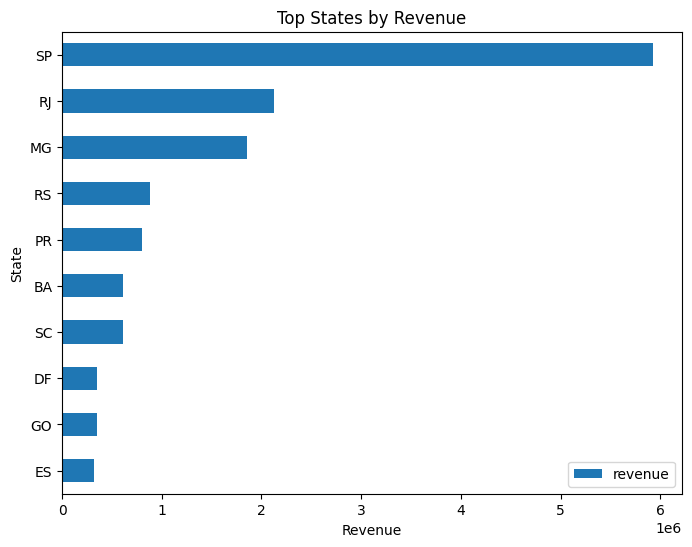

In [8]:
import matplotlib.pyplot as plt

state_revenue.sort_values("revenue").plot(
    x="customer_state",
    y="revenue",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.show()

### Revenue by State Insights

- São Paulo (SP) dominates the platform, generating ~37% of total revenue.
- There is a sharp drop after SP, indicating a highly skewed geographic distribution.
- The revenue pattern follows a long-tail distribution, where a few states drive most of the value.
- The business is highly dependent on a single region, which introduces geographic risk.

In [11]:
query = """
SELECT
    STRFTIME('%Y-%m', order_purchase_timestamp) AS order_month,
    ROUND(SUM(COALESCE(product_revenue, 0)), 2) AS product_revenue,
    ROUND(SUM(COALESCE(total_order_value, 0)), 2) AS total_order_value,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(COALESCE(product_revenue, 0)) / COUNT(DISTINCT order_id), 2) AS avg_product_revenue_per_order
FROM customer_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY order_month
HAVING order_month BETWEEN '2017-01' AND '2018-08'
ORDER BY order_month;
"""

monthly_trend_clean = pd.read_sql_query(query, conn)
monthly_trend_clean

,order_month,product_revenue,total_order_value,total_orders,avg_product_revenue_per_order
0,2017-01,120312.87,137188.49,800,150.39
1,2017-02,247303.02,286280.62,1780,138.93
2,2017-03,374344.30,432048.59,2682,139.58
3,2017-04,359927.23,412422.24,2404,149.72
4,2017-05,506071.14,586190.95,3700,136.78
5,2017-06,433038.60,502963.04,3245,133.45
6,2017-07,498031.48,584971.62,4026,123.70
7,2017-08,573971.68,668204.60,4331,132.53
8,2017-09,624401.69,720398.91,4285,145.72
9,2017-10,664219.43,769312.37,4631,143.43


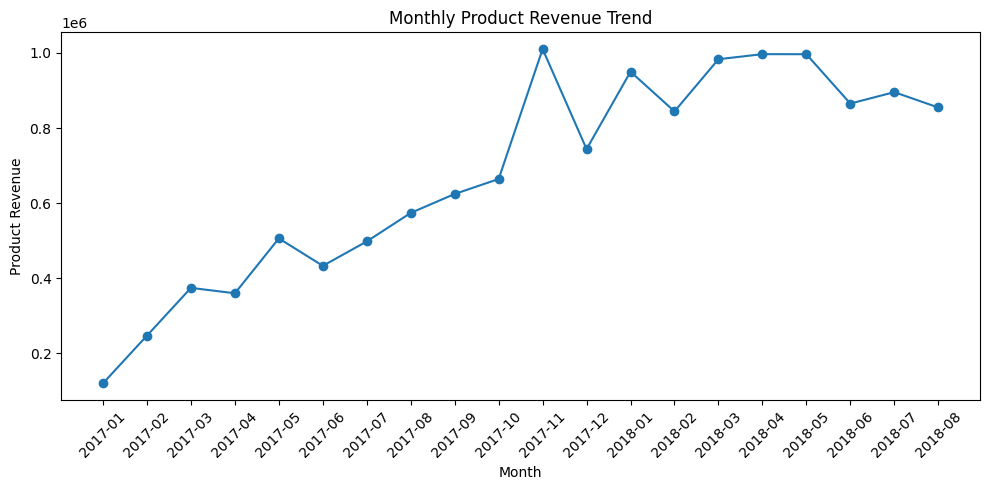

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend_clean["order_month"],
    monthly_trend_clean["product_revenue"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Product Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Product Revenue")
plt.tight_layout()
plt.show()

### Monthly Product Revenue Trend Insights

- Product revenue increased strongly throughout 2017, rising from ~120K in January 2017 to over 1.0M in November 2017.
- The sharp peak in November 2017 suggests a strong seasonal or campaign-related effect, likely connected to year-end shopping behavior.
- In 2018, monthly product revenue remained consistently high, mostly between ~850K and ~1.0M from January to August.
- The growth pattern appears to be mainly volume-driven: monthly orders increased from 800 in January 2017 to more than 7,000 orders in several peak months.
- Average product revenue per order stayed relatively stable, mostly between ~125 and ~145, suggesting that revenue growth was driven more by order volume than by higher order value.
- For trend analysis, incomplete months at the beginning and end of the dataset were excluded to avoid misleading conclusions.

In [15]:
aov_trend = monthly_trend_clean.copy()

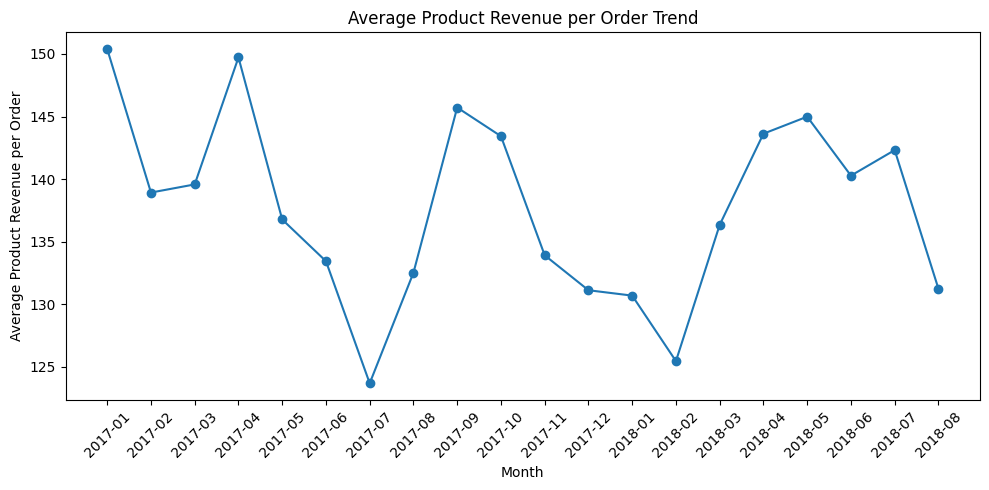

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    aov_trend["order_month"],
    aov_trend["avg_product_revenue_per_order"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Average Product Revenue per Order Trend")
plt.xlabel("Month")
plt.ylabel("Average Product Revenue per Order")
plt.tight_layout()
plt.show()

### Average Product Revenue per Order Insights

- Average product revenue per order remained relatively stable between ~125 and ~150 during the analyzed period.
- There is no strong upward trend in average order value, even though total monthly product revenue increased significantly.
- This suggests that revenue growth was mainly driven by increasing order volume rather than customers spending much more per order.
- The lowest average product revenue per order occurred around July 2017 and February 2018, while higher values appeared in January/April 2017 and April/May 2018.
- This metric should be monitored together with order volume, because revenue growth can come from either more orders or higher average order value.

In [16]:
query = """
SELECT
    primary_product_category,
    ROUND(SUM(COALESCE(product_revenue, 0)), 2) AS product_revenue,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(
        SUM(COALESCE(product_revenue, 0)) / COUNT(DISTINCT order_id),
        2
    ) AS avg_product_revenue_per_order
FROM customer_orders
WHERE primary_product_category IS NOT NULL
GROUP BY primary_product_category
HAVING total_orders >= 50
ORDER BY product_revenue DESC
LIMIT 15;
"""

category_revenue = pd.read_sql_query(query, conn)
category_revenue

,primary_product_category,product_revenue,total_orders,avg_product_revenue_per_order
0,beleza_saude,1259556.23,8802,143.10
1,relogios_presentes,1205725.88,5606,215.08
2,cama_mesa_banho,1043227.89,9351,111.56
3,esporte_lazer,988032.20,7684,128.58
4,informatica_acessorios,913193.16,6671,136.89
5,moveis_decoracao,727520.72,6332,114.90
6,cool_stuff,635073.52,3601,176.36
7,utilidades_domesticas,632754.20,5828,108.57
8,automotivo,593096.78,3880,152.86
9,brinquedos,485223.76,3873,125.28


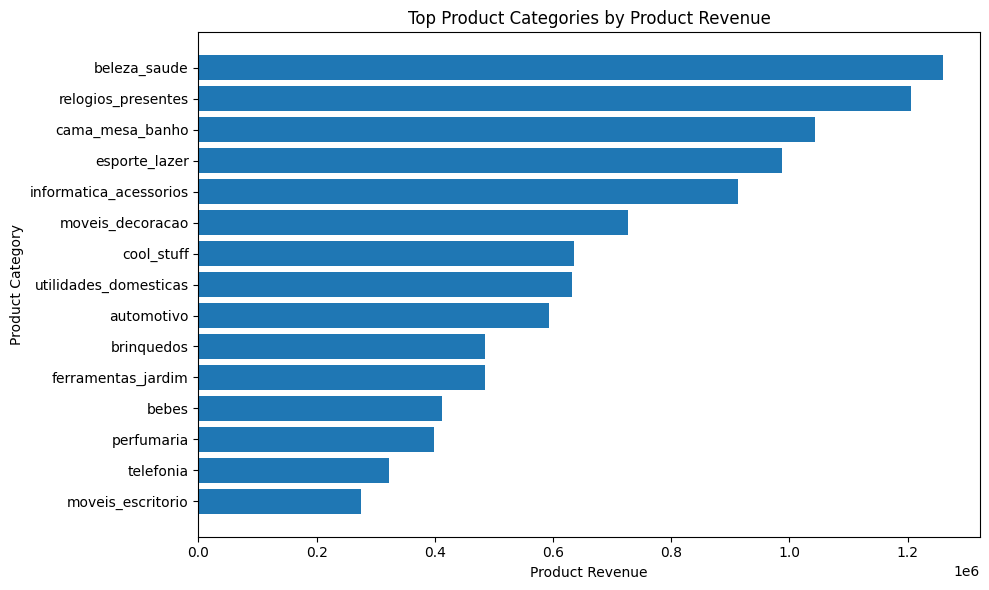

In [17]:
plt.figure(figsize=(10, 6))

plot_df = category_revenue.sort_values("product_revenue")

plt.barh(
    plot_df["primary_product_category"],
    plot_df["product_revenue"]
)

plt.title("Top Product Categories by Product Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Product Category Revenue Insights

- Product revenue is concentrated in a limited number of categories, with `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios` forming the top revenue drivers.
- `beleza_saude` generates the highest product revenue (~1.26M) and also has high order volume, making it a core category for the business.
- `relogios_presentes` generates nearly the same revenue as the top category with fewer orders, because its average product revenue per order is much higher (~215). This suggests it is a higher-ticket category.
- `cama_mesa_banho` has the highest order volume among the top categories, but a lower average product revenue per order (~112), meaning its revenue is mainly volume-driven.
- `telefonia` has relatively high order volume but a low average product revenue per order (~77), so it may be more useful for volume and customer acquisition than for high-value revenue.
- Categories such as `relogios_presentes`, `cool_stuff`, and `moveis_escritorio` show higher average order value, while categories like `cama_mesa_banho`, `utilidades_domesticas`, and `telefonia` rely more on order volume.

In [18]:
query = """
WITH category_revenue AS (
    SELECT
        primary_product_category,
        ROUND(SUM(COALESCE(product_revenue, 0)), 2) AS product_revenue,
        COUNT(DISTINCT order_id) AS total_orders
    FROM customer_orders
    WHERE primary_product_category IS NOT NULL
    GROUP BY primary_product_category
),
total_revenue AS (
    SELECT
        SUM(product_revenue) AS overall_product_revenue
    FROM category_revenue
)
SELECT
    c.primary_product_category,
    c.product_revenue,
    c.total_orders,
    ROUND(
        100.0 * c.product_revenue / t.overall_product_revenue,
        2
    ) AS revenue_share_percent
FROM category_revenue c
CROSS JOIN total_revenue t
ORDER BY c.product_revenue DESC
LIMIT 15;
"""

category_share = pd.read_sql_query(query, conn)
category_share

,primary_product_category,product_revenue,total_orders,revenue_share_percent
0,beleza_saude,1259556.23,8802,9.39
1,relogios_presentes,1205725.88,5606,8.99
2,cama_mesa_banho,1043227.89,9351,7.78
3,esporte_lazer,988032.20,7684,7.36
4,informatica_acessorios,913193.16,6671,6.81
5,moveis_decoracao,727520.72,6332,5.42
6,cool_stuff,635073.52,3601,4.73
7,utilidades_domesticas,632754.20,5828,4.72
8,automotivo,593096.78,3880,4.42
9,brinquedos,485223.76,3873,3.62


In [19]:
category_share["cumulative_revenue_share_percent"] = (
    category_share["revenue_share_percent"].cumsum()
)

category_share

,primary_product_category,product_revenue,total_orders,revenue_share_percent,cumulative_revenue_share_percent
0,beleza_saude,1259556.23,8802,9.39,9.39
1,relogios_presentes,1205725.88,5606,8.99,18.38
2,cama_mesa_banho,1043227.89,9351,7.78,26.16
3,esporte_lazer,988032.20,7684,7.36,33.52
4,informatica_acessorios,913193.16,6671,6.81,40.33
5,moveis_decoracao,727520.72,6332,5.42,45.75
6,cool_stuff,635073.52,3601,4.73,50.48
7,utilidades_domesticas,632754.20,5828,4.72,55.20
8,automotivo,593096.78,3880,4.42,59.62
9,brinquedos,485223.76,3873,3.62,63.24


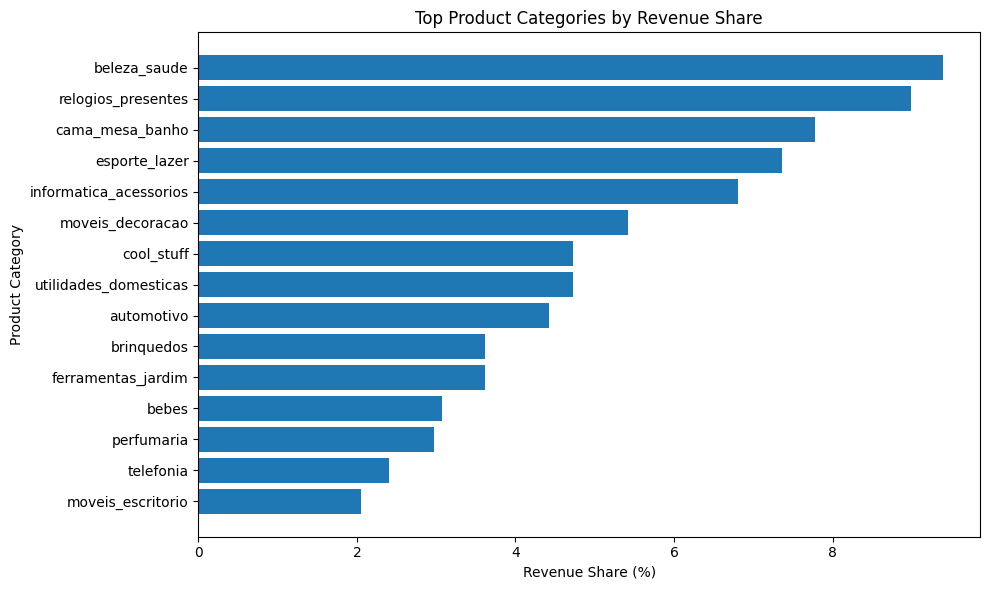

In [20]:
plt.figure(figsize=(10, 6))

plot_df = category_share.sort_values("revenue_share_percent")

plt.barh(
    plot_df["primary_product_category"],
    plot_df["revenue_share_percent"]
)

plt.title("Top Product Categories by Revenue Share")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

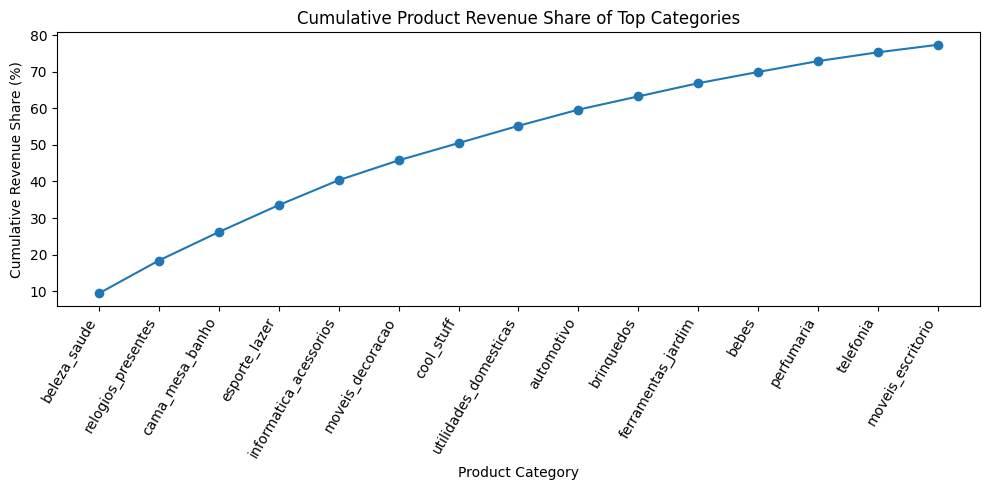

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    category_share["primary_product_category"],
    category_share["cumulative_revenue_share_percent"],
    marker="o"
)

plt.xticks(rotation=60, ha="right")
plt.title("Cumulative Product Revenue Share of Top Categories")
plt.xlabel("Product Category")
plt.ylabel("Cumulative Revenue Share (%)")
plt.tight_layout()
plt.show()

### Category Revenue Share Insights

- Product revenue is distributed across multiple categories rather than being dominated by a single category.
- The top category, `beleza_saude`, contributes only ~9.4% of total product revenue, while the top 5 categories together account for ~40.3%.
- The top 10 categories generate ~63.2% of total product revenue, and the top 15 categories generate ~77.4%.
- This indicates a moderate category concentration: a limited number of categories drive most revenue, but the business is not fully dependent on one product category.
- Compared with geographic revenue, category revenue is more diversified. This reduces category-specific risk but still highlights the importance of managing top-performing categories carefully.
- Categories with high revenue share should be prioritized for inventory planning, pricing analysis, and marketing campaigns, while lower-share categories may require separate profitability or long-tail analysis.